In [230]:
import pandas as pd
import numpy as np
import pickle

from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams
from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report, f1_score,
                             precision_recall_fscore_support)

sns.set(style='whitegrid', palette='muted', font_scale=1.5)
rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Edible", "Poisonous"]

In [231]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [232]:
df = pd.read_csv('/content/drive/MyDrive/AI/MushroomDataset/secondary_data.csv', sep=';')

Исследование данных

In [233]:
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [234]:
print(df.shape)
print(df.describe())

(61069, 21)
       cap-diameter   stem-height    stem-width
count  61069.000000  61069.000000  61069.000000
mean       6.733854      6.581538     12.149410
std        5.264845      3.370017     10.035955
min        0.380000      0.000000      0.000000
25%        3.480000      4.640000      5.210000
50%        5.860000      5.950000     10.190000
75%        8.540000      7.740000     16.570000
max       62.340000     33.920000    103.910000


проверка на пропуски

In [235]:
df.isnull().values.any()

np.True_

пропуски есть, убираем их

смотрим в каких столбцах пропуски

In [236]:
miss = df.isnull().sum()
miss


,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


заменяем пропуски самыми популярными занчениями

In [237]:
df_clean = df.copy()

for col in miss.index:
    most_frequent = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(most_frequent)

In [238]:
df_clean.isnull().values.any()

np.False_

теперь пропусков нету

In [239]:
df_clean['class'].value_counts()

,count
class,
p,33888
e,27181


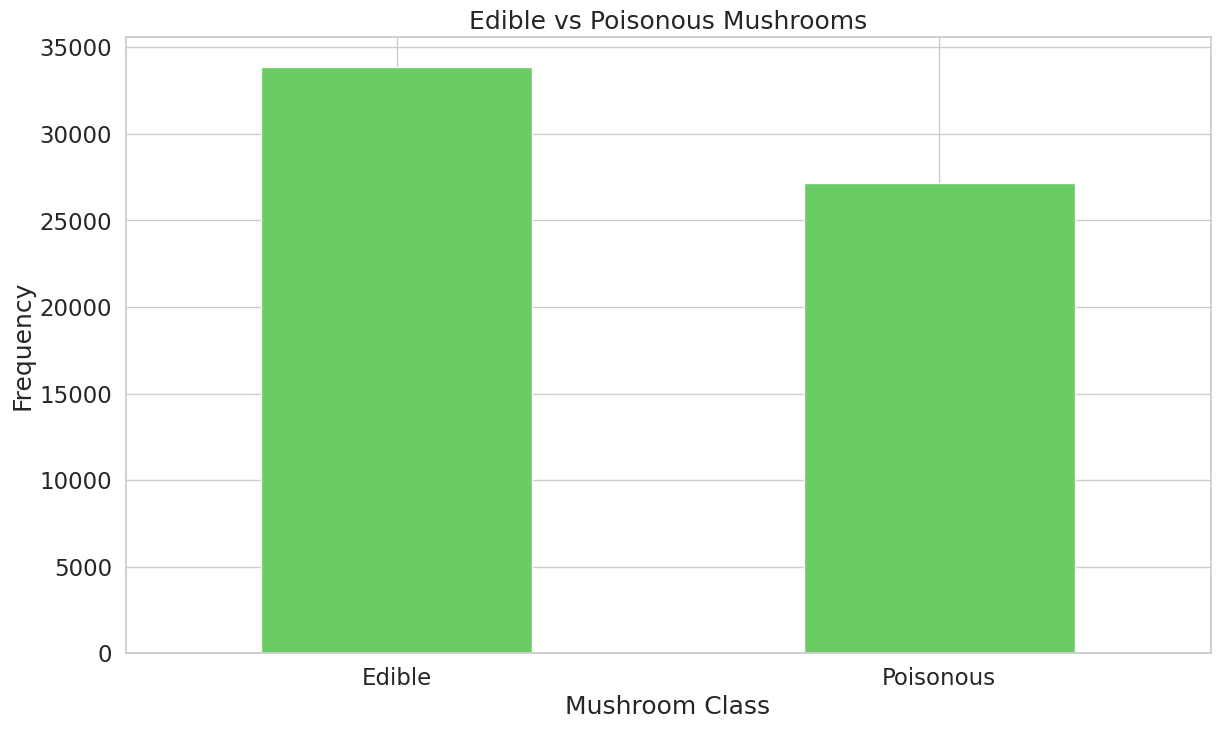

In [240]:
count_classes = df_clean['class'].value_counts(sort=True)
count_classes.plot(kind = 'bar', rot=0, color="g")
plt.title("Edible vs Poisonous Mushrooms")
plt.xticks(range(2), LABELS)
plt.xlabel("Mushroom Class")
plt.ylabel("Frequency");

датасет более менее сбалансирован

In [241]:
edibleDF = df_clean[df_clean['class'] == 'e']
poisonousDF = df_clean[df_clean['class'] == 'p']

In [242]:
edibleDF.shape

(27181, 21)

In [243]:
poisonousDF.shape

(33888, 21)

In [244]:
edibleDF['cap-diameter'].describe()

,cap-diameter
count,27181.000000
mean,7.798696
std,6.373404
min,0.530000
25%,4.290000
50%,6.710000
75%,9.410000
max,62.340000


In [245]:
poisonousDF['cap-diameter'].describe()

,cap-diameter
count,33888.000000
mean,5.879763
std,3.966391
min,0.380000
25%,3.040000
50%,4.980000
75%,7.850000
max,30.340000


график распределения диаметра шляпки у грибов

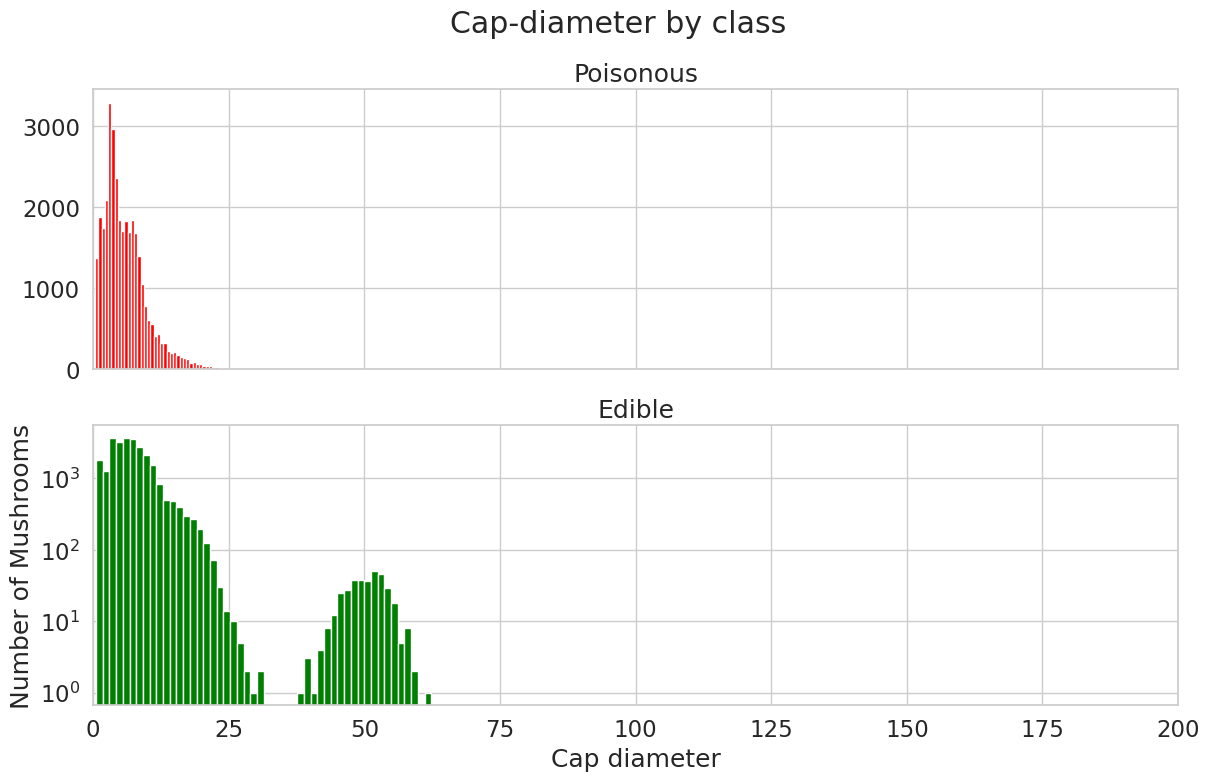

In [246]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Cap-diameter by class')

ax1.hist(poisonousDF['cap-diameter'], bins=50, color='red')
ax1.set_title('Poisonous')

ax2.hist(edibleDF['cap-diameter'], bins=50, color='green')
ax2.set_title('Edible')

plt.xlabel('Cap diameter')
plt.ylabel('Number of Mushrooms')
plt.xlim((0, 200))
plt.yscale('log')
plt.show()

зависимость между диаметром шляпки и высотой ножки

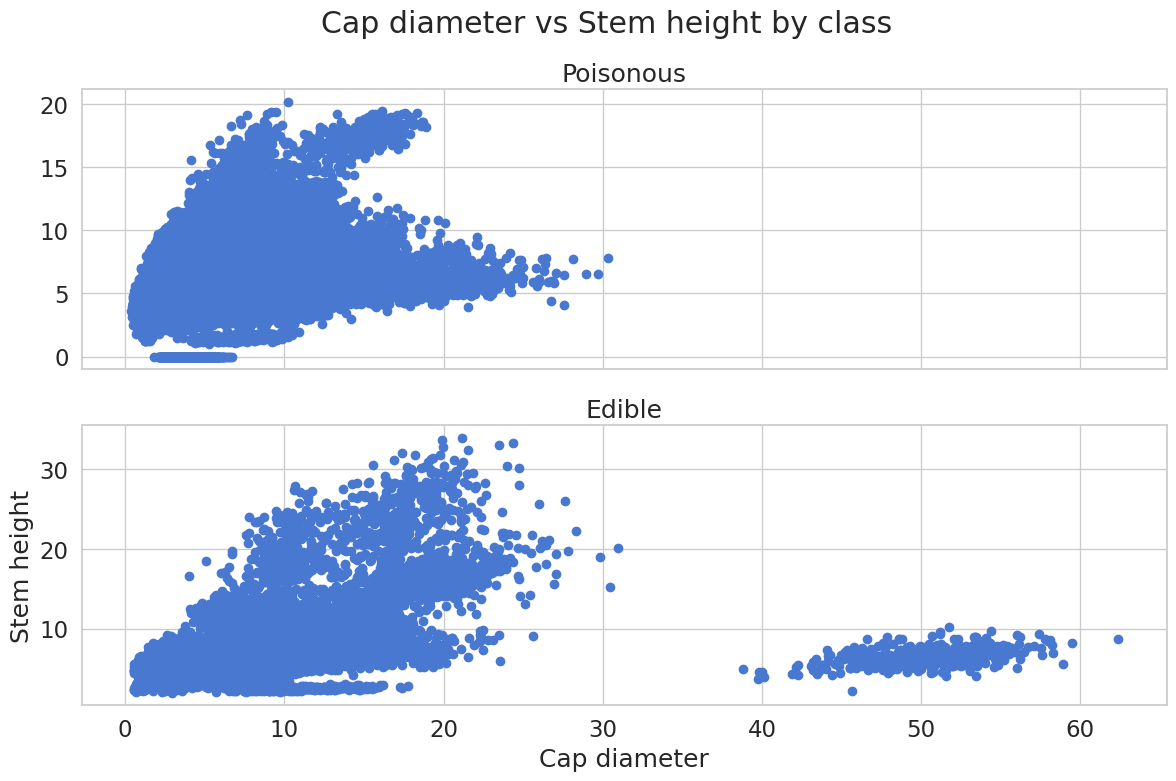

In [247]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Cap diameter vs Stem height by class')

ax1.scatter(poisonousDF['cap-diameter'], poisonousDF['stem-height'])
ax1.set_title('Poisonous')

ax2.scatter(edibleDF['cap-diameter'], edibleDF['stem-height'])
ax2.set_title('Edible')

plt.xlabel('Cap diameter')
plt.ylabel('Stem height')
plt.show()

Предварительная обработка. Берём только числовые признаки

In [344]:
transactionData = df_clean.drop(['class'], axis=1).copy()

стандартизация

In [342]:
numeric_features = ['cap-diameter', 'stem-height', 'stem-width']

In [343]:
scaler = StandardScaler()
transactionData[numeric_features] = scaler.fit_transform(transactionData[numeric_features])

In [292]:
categorical_cols = transactionData.select_dtypes(include=['object']).columns.tolist()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(transactionData[categorical_cols])

encoded_df = pd.DataFrame(encoded_array,columns=encoder.get_feature_names_out(categorical_cols),index=transactionData.index)

transactionData = transactionData.drop(columns=categorical_cols)
transactionData = pd.concat([transactionData, encoded_df], axis=1)

Разделите набор данных на наборы обучающих и тестовых данных

In [293]:
transactionData['class'] = df_clean['class']

X_train, X_test = train_test_split(transactionData, test_size=0.2, random_state=RANDOM_SEED)

X_train = X_train[X_train['class'] == 'e']
X_train = X_train.drop(['class'], axis=1)

y_test = X_test['class']
X_test = X_test.drop(['class'], axis=1)

X_train = X_train.values
X_test = X_test.values
y_test = y_test.values

In [294]:
input_dim = X_train.shape[1]

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        hidden1 = min(64, input_dim // 2)
        hidden2 = min(32, hidden1 // 2)
        bottleneck = min(16, hidden2 // 2)

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.Tanh(),
            nn.Linear(hidden1, hidden2),
            nn.LeakyReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden2, hidden2),
            nn.Tanh(),
            nn.Linear(hidden2, hidden1),
            nn.LeakyReLU(),
            nn.Linear(hidden1, input_dim),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [295]:
model = Autoencoder().double()

In [296]:
num_epochs = 100   # сколько эпох будем обучать. Результаты обучения на одной эпохе используются как начальные для следующей.
minibatch_size = 32
learning_rate = 1e-3

In [297]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float64)
X_test_tensor = torch.tensor(X_test, dtype=torch.float64)

In [298]:
train_loader = data_utils.DataLoader(X_train_tensor, batch_size=32, shuffle=True)
test_loader = data_utils.DataLoader(X_test_tensor, batch_size=1, shuffle=False)

In [299]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
history = {'train_loss': []}

In [300]:
for epoch in range(num_epochs):
    h = np.array([])
    for data in train_loader:
        output = model(data)
        loss = criterion(output, data)
        h = np.append(h, loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    mean_loss = np.mean(h)
    print('epoch [{}/{}], loss:{:.4f}'
          .format(epoch + 1, num_epochs, mean_loss))
    history['train_loss'].append(mean_loss)

torch.save(model.state_dict(), './mushrooms_autoencoder_full.pth')

epoch [1/100], loss:0.0508
epoch [2/100], loss:0.0196
epoch [3/100], loss:0.0145
epoch [4/100], loss:0.0118
epoch [5/100], loss:0.0103
epoch [6/100], loss:0.0093
epoch [7/100], loss:0.0085
epoch [8/100], loss:0.0078
epoch [9/100], loss:0.0072
epoch [10/100], loss:0.0068
epoch [11/100], loss:0.0064
epoch [12/100], loss:0.0060
epoch [13/100], loss:0.0058
epoch [14/100], loss:0.0055
epoch [15/100], loss:0.0053
epoch [16/100], loss:0.0052
epoch [17/100], loss:0.0050
epoch [18/100], loss:0.0048
epoch [19/100], loss:0.0047
epoch [20/100], loss:0.0045
epoch [21/100], loss:0.0044
epoch [22/100], loss:0.0043
epoch [23/100], loss:0.0043
epoch [24/100], loss:0.0042
epoch [25/100], loss:0.0041
epoch [26/100], loss:0.0040
epoch [27/100], loss:0.0040
epoch [28/100], loss:0.0039
epoch [29/100], loss:0.0038
epoch [30/100], loss:0.0038
epoch [31/100], loss:0.0037
epoch [32/100], loss:0.0037
epoch [33/100], loss:0.0036
epoch [34/100], loss:0.0036
epoch [35/100], loss:0.0035
epoch [36/100], loss:0.0035
e

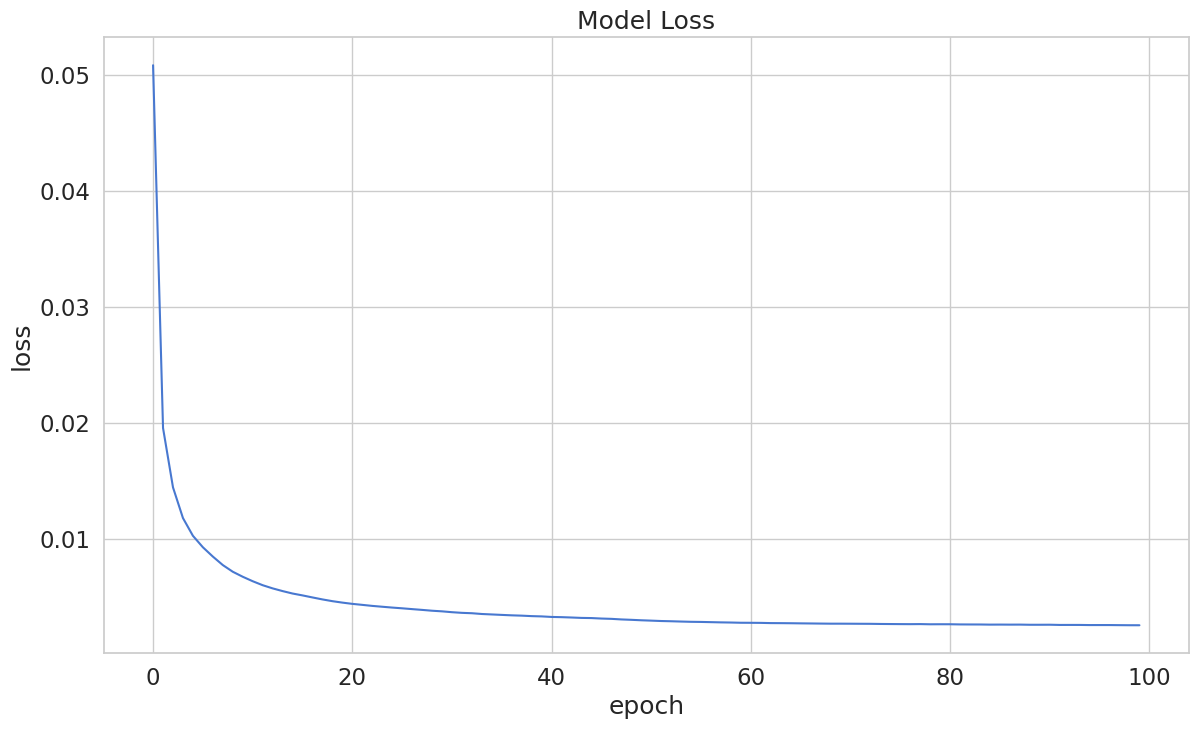

In [301]:
plt.plot(history['train_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

Оценка модели

In [315]:
pred_losses = {'pred_loss' : []}
model.eval()
with torch.no_grad():
    for data in test_loader:
        inputs = data
        outputs = model(inputs)
        loss = criterion(outputs, inputs).data.item()
        pred_losses['pred_loss'].append(loss)
reconstructionErrorDF = pd.DataFrame(pred_losses)
reconstructionErrorDF['class'] = y_test

In [314]:
reconstructionErrorDF.describe()

,pred_loss
count,12214.000000
mean,0.015434
std,0.018373
min,0.000295
25%,0.001705
50%,0.006738
75%,0.025038
max,0.102347


In [310]:
reconstructionErrorDF.describe()

,pred_loss
count,12214.000000
mean,0.015434
std,0.018373
min,0.000295
25%,0.001705
50%,0.006738
75%,0.025038
max,0.102347


перекодируем ЦП

In [346]:
reconstructionErrorDF['Class'] = reconstructionErrorDF['class'].map({'e': 0, 'p': 1})

Reconstruction Errors without Fraud

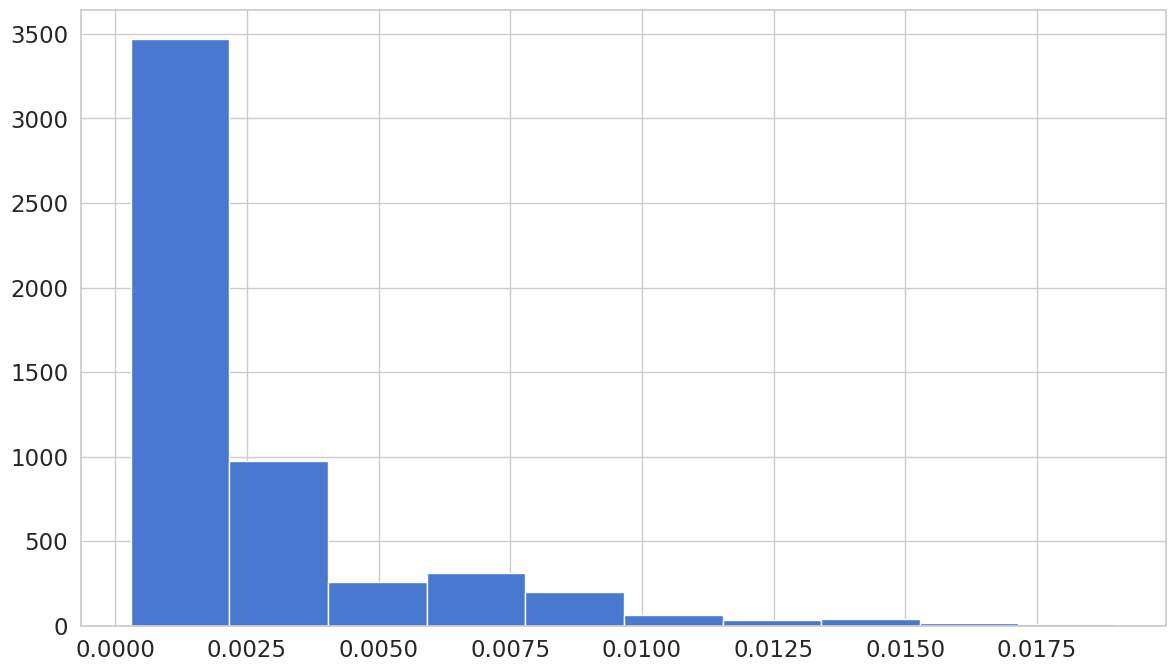

In [347]:
fig = plt.figure()
ax = fig.add_subplot(111)
normal_error_df = reconstructionErrorDF[(reconstructionErrorDF['Class']== 0) & (reconstructionErrorDF['pred_loss'] < 10)]
_ = ax.hist(normal_error_df.pred_loss.values, bins=10)

Reconstruction Errors with Fraud

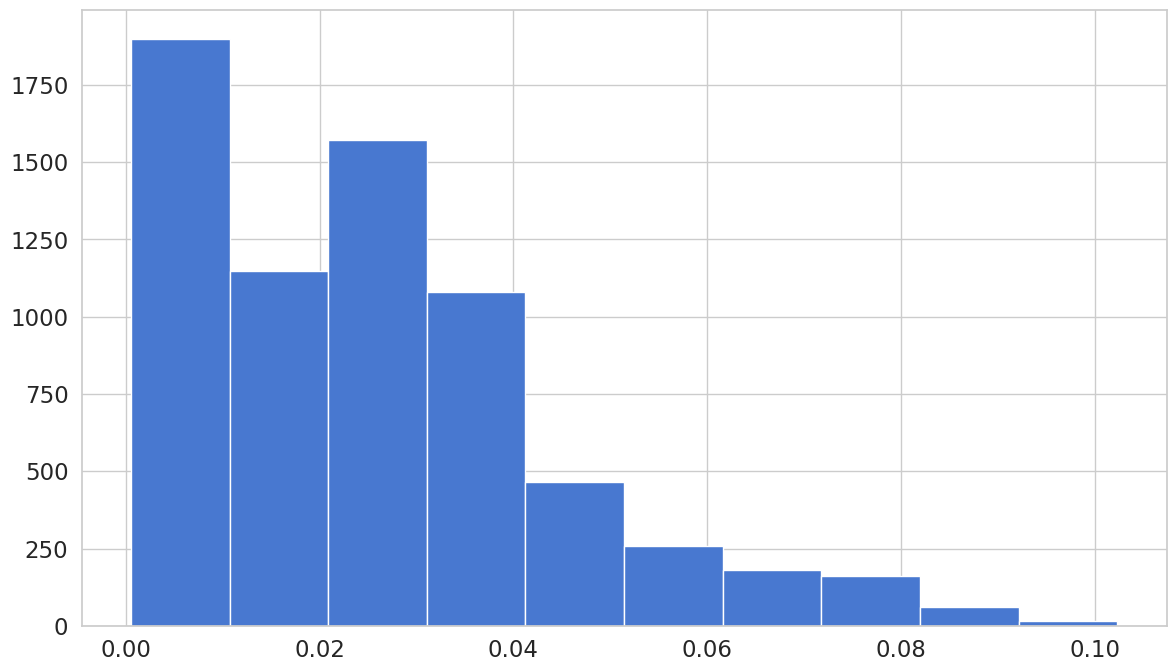

In [348]:
fig = plt.figure()
ax = fig.add_subplot(111)
fraud_error_df = reconstructionErrorDF[(reconstructionErrorDF['Class']== 1) ]
_ = ax.hist(fraud_error_df.pred_loss.values, bins=10)

ROC Curves

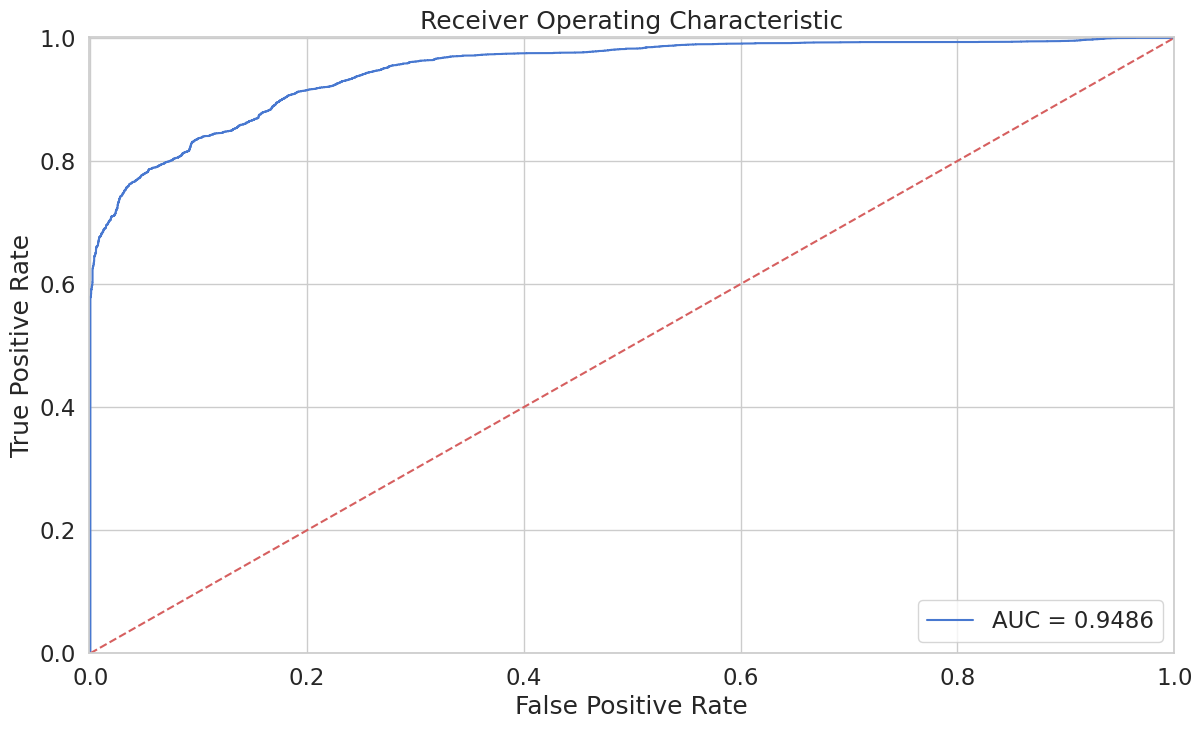

In [349]:
fpr, tpr, thresholds = roc_curve(reconstructionErrorDF.Class, reconstructionErrorDF.pred_loss)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, label='AUC = %0.4f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();

Precision vs Recall

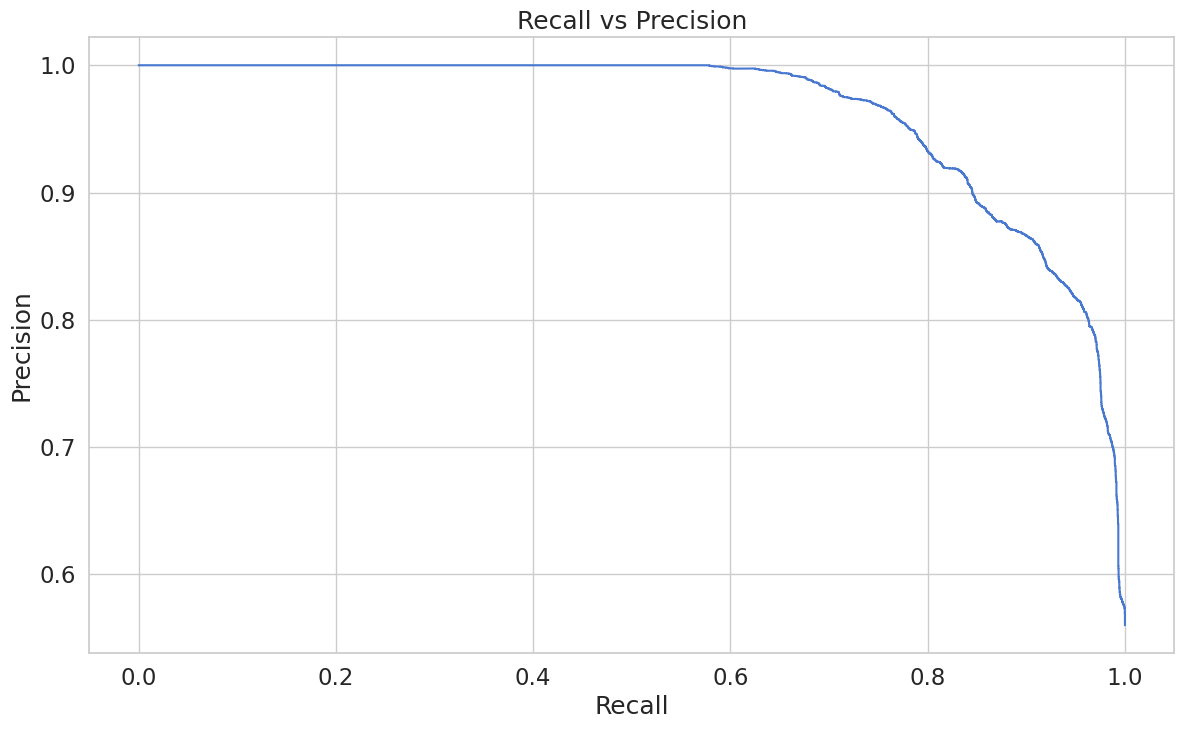

In [350]:
precision, recall, th = precision_recall_curve(reconstructionErrorDF.Class, reconstructionErrorDF.pred_loss)
plt.plot(recall, precision, 'b', label='Precision-Recall curve')
plt.title('Recall vs Precision')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

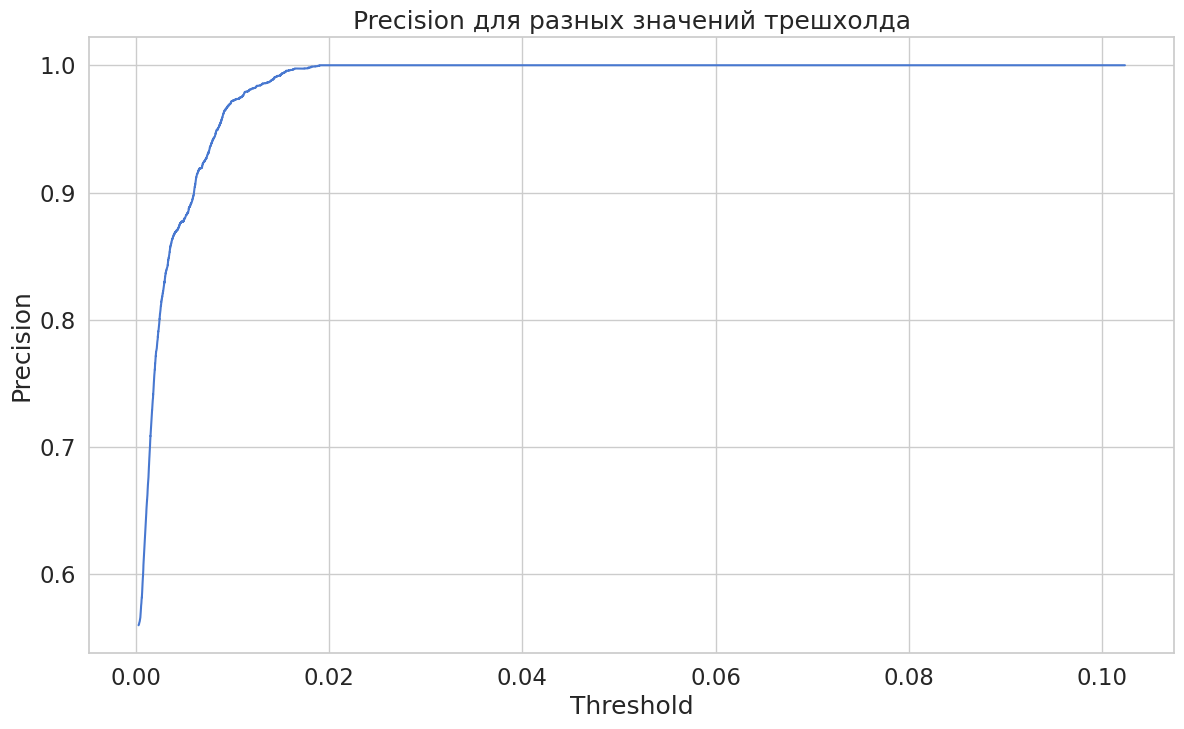

In [351]:
plt.plot(th, precision[1:], 'b', label='Threshold-Precision curve')
plt.title('Precision для разных значений трешхолда')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.show()

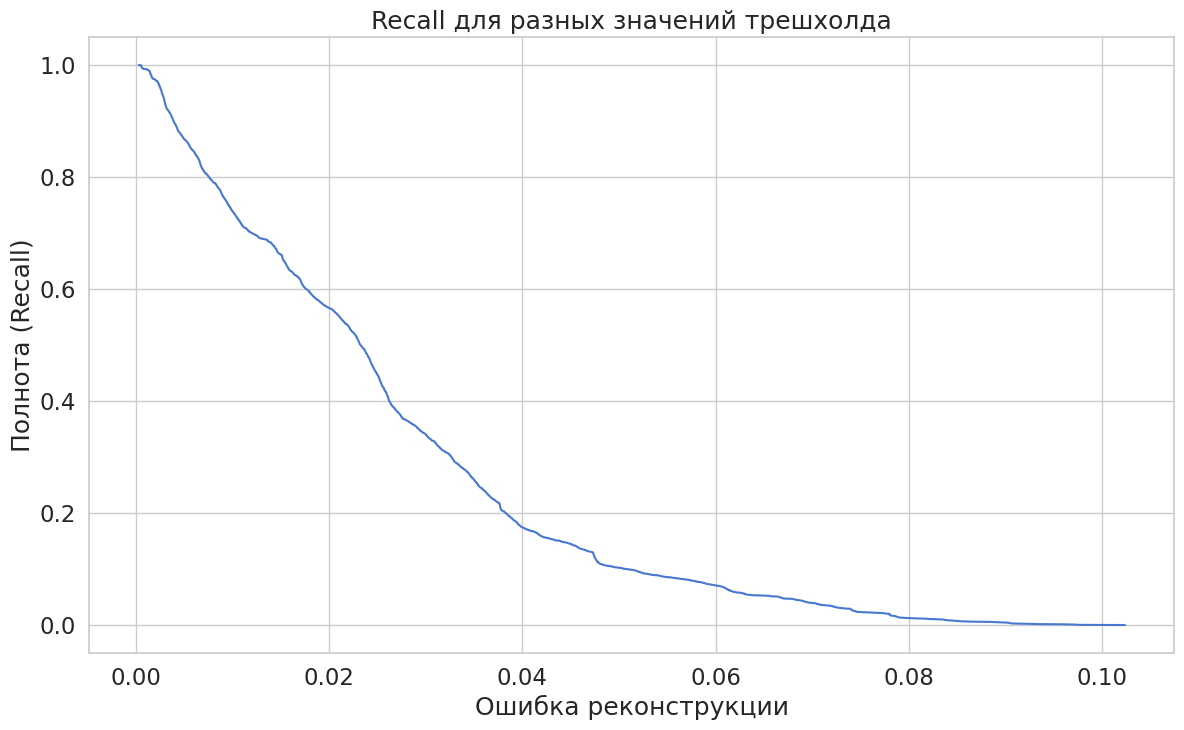

In [352]:
plt.plot(th, recall[1:], 'b', label='Threshold-Recall curve')
plt.title('Recall для разных значений трешхолда')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Полнота (Recall)')
plt.show()

Используем модель для того, чтобы сделать предсказание

In [362]:
threshold = 0.05

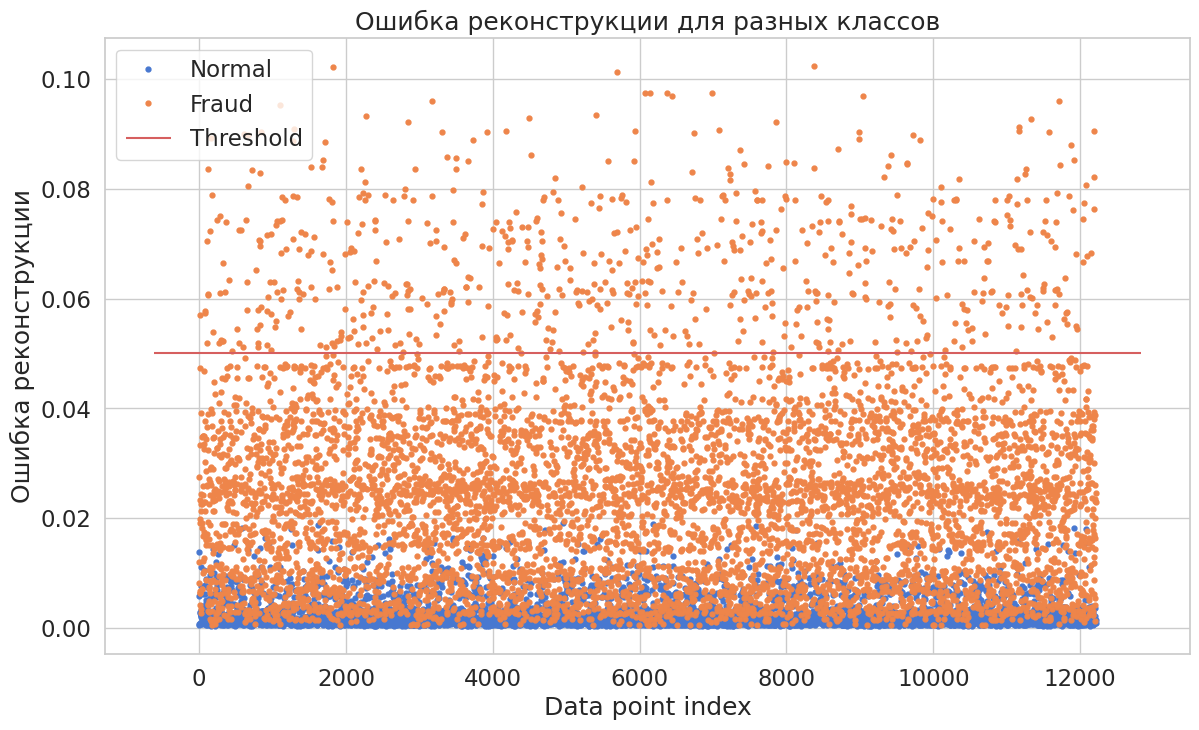

In [363]:
groups = reconstructionErrorDF.groupby('Class')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.pred_loss, marker='o', ms=3.5, linestyle='',
            label= "Fraud" if name == 1 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Ошибка реконструкции для разных классов")
plt.ylabel("Ошибка реконструкции")
plt.xlabel("Data point index")
plt.show();

Построим и посмотрим confusion matrix:

/tmp/ipykernel_7540/58588941.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Blues'));


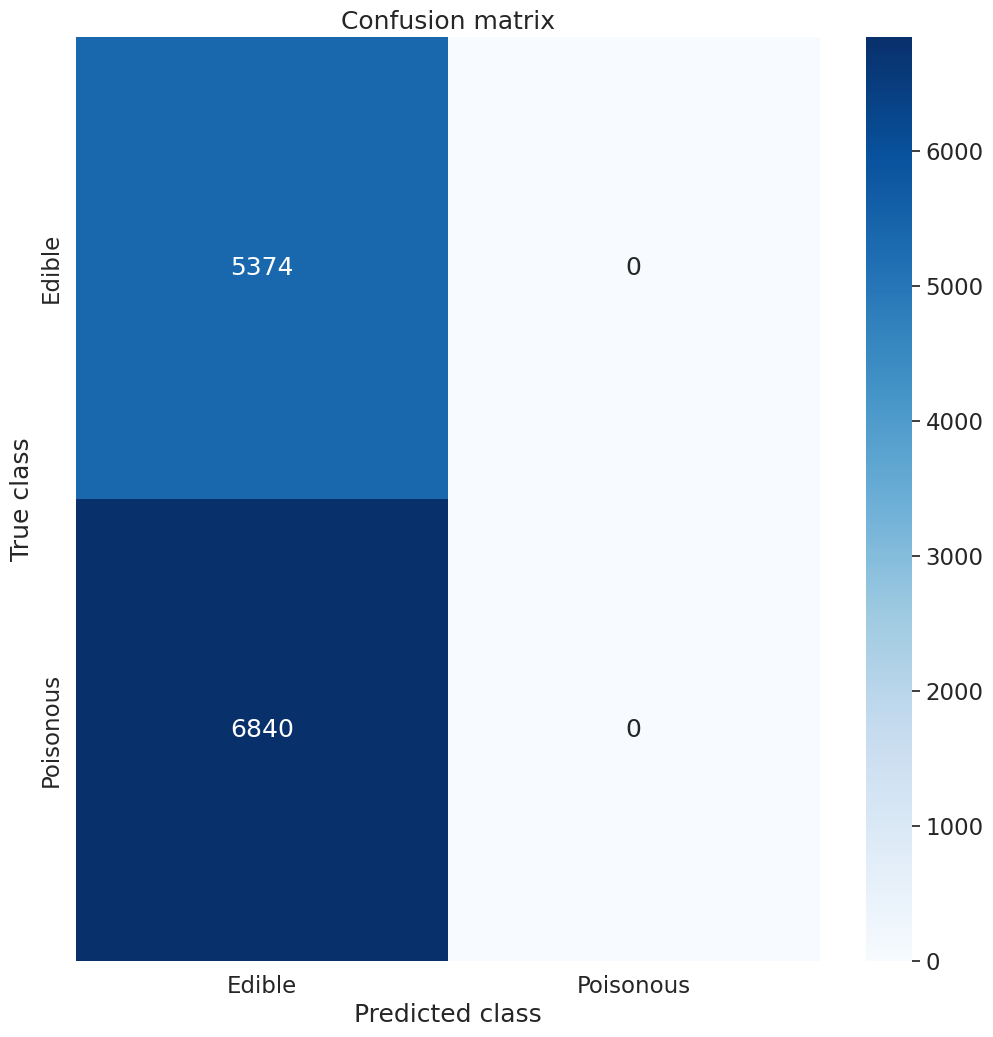

In [355]:
y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF.pred_loss.values]
conf_matrix = confusion_matrix(reconstructionErrorDF.Class, y_pred)
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",
            cmap=plt.cm.get_cmap('Blues'));
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

Вывод:
Для нашего датасета автоэнкодер неэффективен, потому что:
Большинство признаков бинарные (после one-hot)